# HIFtool DBIN — HARVARD Dataset Evaluation

This notebook implements the **Deep Blind Image Super-Resolution (DBIN)** method for hyperspectral image fusion and evaluates it on the **Harvard** dataset.

### Method Overview
DBIN is a dual-branch interacting network designed for hyperspectral image super-resolution. It utilizes iterative Laplacian boosting and spectral normalization to achieve high-fidelity reconstructions.

### Evaluation Setup
- **Dataset**: Harvard (31 bands, center-cropped to 512x512)
- **Scale Factor**: 16
- **Checkpoint**: `model-sf16-15k`
- **Metrics**: PSNR, SSIM, SAM, ERGAS

In [1]:
# Install dependencies
!pip install -q "tensorflow<2.16" numpy scipy scikit-image opencv-python-headless sewar tabulate
print("✓ Dependencies installed")

ERROR: Could not find a version that satisfies the requirement tensorflow<2.16 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow<2.16
✓ Dependencies installed


In [2]:
import os
import sys
import glob
import time
import numpy as np
import scipy.io as sio
import tensorflow as tf
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate

try:
    import cv2
except Exception:
    cv2 = None

try:
    from skimage.metrics import structural_similarity as compare_ssim
    from skimage.metrics import peak_signal_noise_ratio as compare_psnr
except Exception:
    from skimage.measure import compare_ssim
    from skimage.measure import compare_psnr

# Enable TF1 compatibility mode
if tf.__version__.startswith('2'):
    tf.compat.v1.disable_eager_execution()

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.test.is_gpu_available()}")

TensorFlow version: 2.20.0
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU Available: True


I0000 00:00:1784021999.936180      58 gpu_device.cc:2020] Created device /device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784021999.939395      58 gpu_device.cc:2020] Created device /device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 1. Model Architecture

Implementation of DBIN's core components: Fusion module, Laplacian Boosting, and Spectral Normalization.

In [3]:
def _vsi():
    return tf.compat.v1.variance_scaling_initializer()

def lrelu(x, alpha=0.2):
    return tf.nn.leaky_relu(x, alpha)

def global_avg_pool(x):
    return tf.reduce_mean(x, axis=[1, 2])

def dense_manual(x, units, activation_fn=None, scope='dense'):
    with tf.compat.v1.variable_scope(scope, reuse=tf.compat.v1.AUTO_REUSE):
        in_dim = x.get_shape().as_list()[-1]
        w = tf.compat.v1.get_variable('kernel', shape=[in_dim, units], initializer=_vsi())
        b = tf.compat.v1.get_variable('bias', shape=[units], initializer=tf.zeros_initializer())
        y = tf.matmul(x, w) + b
        if activation_fn is not None:
            y = activation_fn(y)
        return y

def spectral_norm(w, iteration=1):
    w_shape = w.shape.as_list()
    w_reshaped = tf.reshape(w, [-1, w_shape[-1]])
    u = tf.compat.v1.get_variable('u', [1, w_shape[-1]], initializer=tf.random_normal_initializer(), trainable=False)
    u_hat = u
    for _ in range(iteration):
        v_ = tf.matmul(u_hat, tf.transpose(w_reshaped))
        v_hat = tf.nn.l2_normalize(v_)
        u_ = tf.matmul(v_hat, w_reshaped)
        u_hat = tf.nn.l2_normalize(u_)
    u_hat = tf.stop_gradient(u_hat)
    v_hat = tf.stop_gradient(v_hat)
    sigma = tf.matmul(tf.matmul(v_hat, w_reshaped), tf.transpose(u_hat))
    with tf.control_dependencies([u.assign(u_hat)]):
        w_norm = w_reshaped / sigma * 0.7
        w_norm = tf.reshape(w_norm, w_shape)
    return w_norm

def conv_sn(x, channels, weight_decay, kernel=3, stride=1, use_bias=True, scope='conv'):
    with tf.compat.v1.variable_scope(scope, reuse=tf.compat.v1.AUTO_REUSE):
        w = tf.compat.v1.get_variable('kernel', shape=[kernel, kernel, x.get_shape()[-1], channels], initializer=_vsi())
        bias = tf.compat.v1.get_variable('bias', [channels], initializer=tf.constant_initializer(0.0))
        y = tf.nn.conv2d(input=x, filters=spectral_norm(w), strides=[1, stride, stride, 1], padding='SAME')
        if use_bias: y = tf.nn.bias_add(y, bias)
        return y

def upsample(x, ref):
    target_hw = tf.shape(ref)[1:3]
    return tf.image.resize(x, target_hw, method=tf.image.ResizeMethod.BILINEAR)

def Fusion(Z, Y, weight_decay, num_spectral=31, num_fm=64, reuse=True):
    with tf.compat.v1.variable_scope('py'):
        if reuse: tf.compat.v1.get_variable_scope().reuse_variables()
        lms = upsample(Y, Z)
        Xin = tf.concat([lms, Z], axis=3)
        Xt = conv_sn(Xin, num_fm, weight_decay, scope='in')
        Xt = lrelu(Xt)
        for i in range(4):
            Xi = conv_sn(Xt, num_fm, weight_decay, scope=f'res{i}1')
            Xi = lrelu(Xi)
            Xi = conv_sn(Xi, num_fm, weight_decay, scope=f'res{i}2')
            mask = global_avg_pool(Xi)
            mask = dense_manual(mask, units=num_fm // 16, activation_fn=tf.nn.relu, scope=f'se{i}1')
            mask = dense_manual(mask, units=num_fm, activation_fn=None, scope=f'se{i}2')
            mask = tf.reshape(mask, [-1, 1, 1, num_fm])
            mask = tf.sigmoid(mask)
            Xi = tf.multiply(Xi, mask)
            Xt = Xt + Xi
        return conv_sn(Xt, num_spectral, weight_decay, scope='out')

def boost_lap(X, Z_in, Y_in, weight_decay, num_spectral=31, num_fm=64, sf=8, reuse=True):
    with tf.compat.v1.variable_scope('recursive'):
        if reuse: tf.compat.v1.get_variable_scope().reuse_variables()
        Z = conv_sn(X, 3, weight_decay, scope='dz')
        Z = lrelu(Z)
        dy_kernel = int(sf) + 4
        Y = conv_sn(X, num_spectral, weight_decay, kernel=dy_kernel, stride=int(sf), scope='dy')
        Y = lrelu(Y)
        dZ, dY = Z_in - Z, Y_in - Y
        dX = Fusion(dZ, dY, weight_decay, num_spectral=num_spectral, num_fm=num_fm, reuse=True)
        return X + dX

def fusion_net(Z, Y, num_spectral=31, num_fm=64, num_ite=8, sf=8, reuse=False, weight_decay=1e-5):
    with tf.compat.v1.variable_scope('fusion_net'):
        if reuse: tf.compat.v1.get_variable_scope().reuse_variables()
        X = Fusion(Z, Y, weight_decay, num_spectral=num_spectral, num_fm=num_fm, reuse=False)
        Xs = X
        for _ in range(num_ite):
            X = boost_lap(X, Z, Y, weight_decay, num_spectral=num_spectral, num_fm=num_fm, sf=sf, reuse=True)
            Xs = tf.concat([Xs, X], axis=3)
        return conv_sn(Xs, num_spectral, weight_decay, use_bias=False, scope='out_conv')

## 2. Data Utilities

Functions to handle MAT loading, TFRecord conversion, and metric calculation.

In [4]:
def _normalize01(x):
    x = np.asarray(x, dtype=np.float32)
    mx = float(np.nanmax(x)) if x.size else 1.0
    if mx > 1.0:
        denom = 255.0 if mx <= 255.0 else (4095.0 if mx <= 4095.0 else (65535.0 if mx <= 65535.0 else mx))
        x = x / denom
    return np.clip(x, 0.0, 1.0)

def _bytes_feature(value): return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def convert_mats_to_test_tfrecord(mat_dir, save_path, sf=16, crop_size=512):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    writer = tf.io.TFRecordWriter(save_path)
    mats = sorted([f for f in os.listdir(mat_dir) if f.endswith('.mat')])
    count = 0
    for fname in mats:
        path = os.path.join(mat_dir, fname)
        try:
            m = sio.loadmat(path)
        except NotImplementedError:
            import h5py
            with h5py.File(path, 'r') as f: m = {k: np.array(v).T for k, v in f.items()}
            
        data = None
        for k in ['hsi', 'gt', 'HSI', 'ref', 'data']: 
            if k in m: data = m[k]; break
        if data is None: continue
        
        # Handle Harvard dimension order (C, H, W) or (H, W, C)
        if data.ndim == 3:
            if data.shape[0] <= 31: data = data.transpose(1, 2, 0)
            
        gt = _normalize01(data)
        H, W, C = gt.shape
        if H < crop_size or W < crop_size: continue
        
        y0, x0 = (H - crop_size) // 2, (W - crop_size) // 2
        gt = gt[y0:y0+crop_size, x0:x0+crop_size, :31] # Ensure 31 bands
        
        pan = np.stack([gt[..., 7], gt[..., 15], gt[..., 23]], axis=-1)
        pan2 = cv2.resize(pan, (crop_size // 2, crop_size // 2), interpolation=cv2.INTER_AREA)
        pan4 = cv2.resize(pan, (crop_size // 4, crop_size // 4), interpolation=cv2.INTER_AREA)
        ms = cv2.resize(gt, (crop_size // sf, crop_size // sf), interpolation=cv2.INTER_AREA)
        ms2 = cv2.resize(ms, (crop_size // (sf // 2), crop_size // (sf // 2)), interpolation=cv2.INTER_LINEAR)
        
        example = tf.train.Example(features=tf.train.Features(feature={
            'pan_raw': _bytes_feature(pan.tobytes()), 'pan2_raw': _bytes_feature(pan2.tobytes()),
            'pan4_raw': _bytes_feature(pan4.tobytes()), 'gt_raw': _bytes_feature(gt.tobytes()),
            'ms_raw': _bytes_feature(ms.tobytes()), 'ms2_raw': _bytes_feature(ms2.tobytes()),
        }))
        writer.write(example.SerializeToString())
        count += 1
        
    writer.close()
    return count

def read_and_decode_test_sf(tfrecords_file, batch_size, image_size, sf):
    filename_queue = tf.compat.v1.train.string_input_producer([tfrecords_file])
    reader = tf.compat.v1.TFRecordReader()
    _, serialized_example = reader.read(filename_queue)
    features = tf.compat.v1.parse_single_example(serialized_example, features={
        'pan_raw': tf.io.FixedLenFeature([], tf.string), 'pan2_raw': tf.io.FixedLenFeature([], tf.string),
        'pan4_raw': tf.io.FixedLenFeature([], tf.string), 'gt_raw': tf.io.FixedLenFeature([], tf.string),
        'ms_raw': tf.io.FixedLenFeature([], tf.string), 'ms2_raw': tf.io.FixedLenFeature([], tf.string),
    })
    pan = tf.reshape(tf.io.decode_raw(features['pan_raw'], tf.float32), [image_size, image_size, 3])
    pan2 = tf.reshape(tf.io.decode_raw(features['pan2_raw'], tf.float32), [image_size // 2, image_size // 2, 3])
    pan4 = tf.reshape(tf.io.decode_raw(features['pan4_raw'], tf.float32), [image_size // 4, image_size // 4, 3])
    gt = tf.reshape(tf.io.decode_raw(features['gt_raw'], tf.float32), [image_size, image_size, 31])
    ms = tf.reshape(tf.io.decode_raw(features['ms_raw'], tf.float32), [image_size // sf, image_size // sf, 31])
    ms2 = tf.reshape(tf.io.decode_raw(features['ms2_raw'], tf.float32), [image_size // (sf // 2), image_size // (sf // 2), 31])
    return tf.compat.v1.train.batch([pan, pan2, pan4, gt, ms, ms2], batch_size=batch_size, num_threads=4, capacity=300)

def compute_metrics(gt, pred, sf):
    psnr = compare_psnr(gt, pred, data_range=1.0)
    ssim = np.mean([compare_ssim(gt[..., i], pred[..., i], data_range=1.0) for i in range(gt.shape[-1])])
    # SAM
    numerator = np.sum(gt * pred, axis=-1)
    denominator = np.linalg.norm(gt, axis=-1) * np.linalg.norm(pred, axis=-1) + 1e-10
    sam = np.mean(np.arccos(np.clip(numerator / denominator, -1, 1))) * 180 / np.pi
    # ERGAS
    rmse = np.sqrt(np.mean((gt - pred)**2, axis=(0, 1)))
    mean_gt = np.mean(gt, axis=(0, 1)) + 1e-10
    ergas = (100 / sf) * np.sqrt(np.mean((rmse / mean_gt)**2))
    return psnr, ssim, sam, ergas

## 3. Evaluation Setup

Configuring paths and loading the model checkpoint.

In [5]:
# Configuration
DATA_DIR = "/kaggle/input/harvard-hsi-2/Data/Test/HSI"
if not os.path.exists(DATA_DIR):
    possible = glob.glob("/kaggle/input/**/harvard**/Data/Test/HSI", recursive=True)
    if possible: DATA_DIR = possible[0]

CKPT_DIR = "/kaggle/input/model-sf16-15k/tensorflow2/default/1"
SF = 16
IMG_SIZE = 512
BATCH_SIZE = 1

print(f"Data Directory: {DATA_DIR}")
print(f"Checkpoint Directory: {CKPT_DIR}")

# Convert MATs to TFRecord
TFRECORD_PATH = "./test_harvard_sf16.tfrecords"
num_test = convert_mats_to_test_tfrecord(DATA_DIR, TFRECORD_PATH, sf=SF, crop_size=IMG_SIZE)
print(f"✓ Converted {num_test} images to TFRecord")

# Build Graph
tf.compat.v1.reset_default_graph()
pan_p = tf.compat.v1.placeholder(tf.float32, [BATCH_SIZE, IMG_SIZE, IMG_SIZE, 3])
ms_p = tf.compat.v1.placeholder(tf.float32, [BATCH_SIZE, IMG_SIZE // SF, IMG_SIZE // SF, 31])
gt_p = tf.compat.v1.placeholder(tf.float32, [BATCH_SIZE, IMG_SIZE, IMG_SIZE, 31])

output = fusion_net(pan_p, ms_p, sf=SF)
output = tf.clip_by_value(output, 0.0, 1.0)

pan_batch, pan2_batch, pan4_batch, gt_batch, ms_batch, ms2_batch = read_and_decode_test_sf(TFRECORD_PATH, BATCH_SIZE, IMG_SIZE, SF)

saver = tf.compat.v1.train.Saver()
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True

Data Directory: /kaggle/input/harvard-hsi-2/Data/Test/HSI
Checkpoint Directory: /kaggle/input/model-sf16-15k/tensorflow2/default/1
✓ Converted 20 images to TFRecord
Instructions for updating:
Queue-based input pipelines have been replaced by `tf.data`. Use `tf.data.Dataset.from_tensor_slices(string_tensor).shuffle(tf.shape(input_tensor, out_type=tf.int64)[0]).repeat(num_epochs)`. If `shuffle=False`, omit the `.shuffle(...)`.
Instructions for updating:
Queue-based input pipelines have been replaced by `tf.data`. Use `tf.data.Dataset.from_tensor_slices(input_tensor).shuffle(tf.shape(input_tensor, out_type=tf.int64)[0]).repeat(num_epochs)`. If `shuffle=False`, omit the `.shuffle(...)`.
Instructions for updating:
Queue-based input pipelines have been replaced by `tf.data`. Use `tf.data.Dataset.from_tensors(tensor).repeat(num_epochs)`.
Instructions for updating:
To construct input pipelines, use the `tf.data` module.
Instructions for updating:
To construct input pipelines, use the `tf.data`

## 4. Run Inference

Executing the model on test images and collecting performance metrics.

In [6]:
results = []
visualizations = []

with tf.compat.v1.Session(config=config) as sess:
    sess.run(tf.compat.v1.global_variables_initializer())
    coord = tf.compat.v1.train.Coordinator()
    threads = tf.compat.v1.train.start_queue_runners(sess=sess, coord=coord)
    
    # Restore Checkpoint
    ckpt = tf.train.latest_checkpoint(CKPT_DIR)
    if not ckpt: # Manual search if latest_checkpoint fails
        indices = glob.glob(os.path.join(CKPT_DIR, "*.index"))
        if indices: ckpt = indices[0].replace(".index", "")
    
    if ckpt:
        print(f"Restoring from {ckpt}...")
        saver.restore(sess, ckpt)
    else:
        print("ERROR: Checkpoint not found!")
    
    for i in range(num_test):
        try:
            pan, gt, ms = sess.run([pan_batch, gt_batch, ms_batch])
            start_t = time.time()
            out = sess.run(output, feed_dict={pan_p: pan, ms_p: ms, gt_p: gt})
            elapsed = time.time() - start_t
            
            p, s, sam, e = compute_metrics(gt[0], out[0], SF)
            results.append([f"Image {i+1}", p, s, sam, e, elapsed])
            print(f"Image {i+1:02d}: PSNR={p:.2f}, SSIM={s:.4f}, SAM={sam:.2f}, ERGAS={e:.2f} ({elapsed:.2f}s)")
            
            if i < 4:
                visualizations.append({'gt': gt[0], 'out': out[0]})
        except tf.errors.OutOfRangeError:
            break
            
    coord.request_stop()
    coord.join(threads)

# Summary Table
if results:
    headers = ["Image", "PSNR (dB)", "SSIM", "SAM (deg)", "ERGAS", "Time (s)"]
    print("\n" + "="*75)
    print(f"{'DBIN HARVARD EVALUATION SUMMARY':^75}")
    print("="*75)
    print(tabulate(results, headers=headers, tablefmt="github", floatfmt=".4f"))

    avg_metrics = np.mean(np.array(results)[:, 1:].astype(float), axis=0)
    print("-"*75)
    print(f"{'AVERAGE':<10} {avg_metrics[0]:>10.4f} {avg_metrics[1]:>10.4f} {avg_metrics[2]:>10.4f} {avg_metrics[3]:>10.4f} {avg_metrics[4]:>10.4f}")
    print("="*75)

I0000 00:00:1784022051.500577      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784022051.502186      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1784022051.557513      58 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


Instructions for updating:
To construct input pipelines, use the `tf.data` module.
Restoring from /kaggle/input/model-sf16-15k/tensorflow2/default/1/model-15000.ckpt...
INFO:tensorflow:Restoring parameters from /kaggle/input/model-sf16-15k/tensorflow2/default/1/model-15000.ckpt
Image 01: PSNR=52.78, SSIM=0.9652, SAM=26.16, ERGAS=11.25 (6.93s)
Image 02: PSNR=56.44, SSIM=0.9930, SAM=6.81, ERGAS=1.48 (0.56s)
Image 03: PSNR=52.42, SSIM=0.9795, SAM=20.24, ERGAS=9.26 (0.46s)
Image 04: PSNR=48.44, SSIM=0.9529, SAM=21.51, ERGAS=7.67 (2.50s)
Image 05: PSNR=46.95, SSIM=0.9292, SAM=23.26, ERGAS=12.77 (0.52s)
Image 06: PSNR=56.81, SSIM=0.9900, SAM=16.23, ERGAS=4.97 (0.46s)
Image 07: PSNR=51.40, SSIM=0.9787, SAM=13.23, ERGAS=5.29 (0.47s)
Image 08: PSNR=44.33, SSIM=0.9393, SAM=17.72, ERGAS=9.35 (0.46s)
Image 09: PSNR=52.98, SSIM=0.9813, SAM=22.70, ERGAS=8.44 (0.46s)
Image 10: PSNR=58.76, SSIM=0.9905, SAM=20.85, ERGAS=6.09 (0.47s)
Image 11: PSNR=50.47, SSIM=0.9639, SAM=20.52, ERGAS=9.81 (0.53s)
Image

## 5. Visual Results

Comparing Ground Truth (GT) RGB projections with DBIN reconstructions and visualizing the error maps.

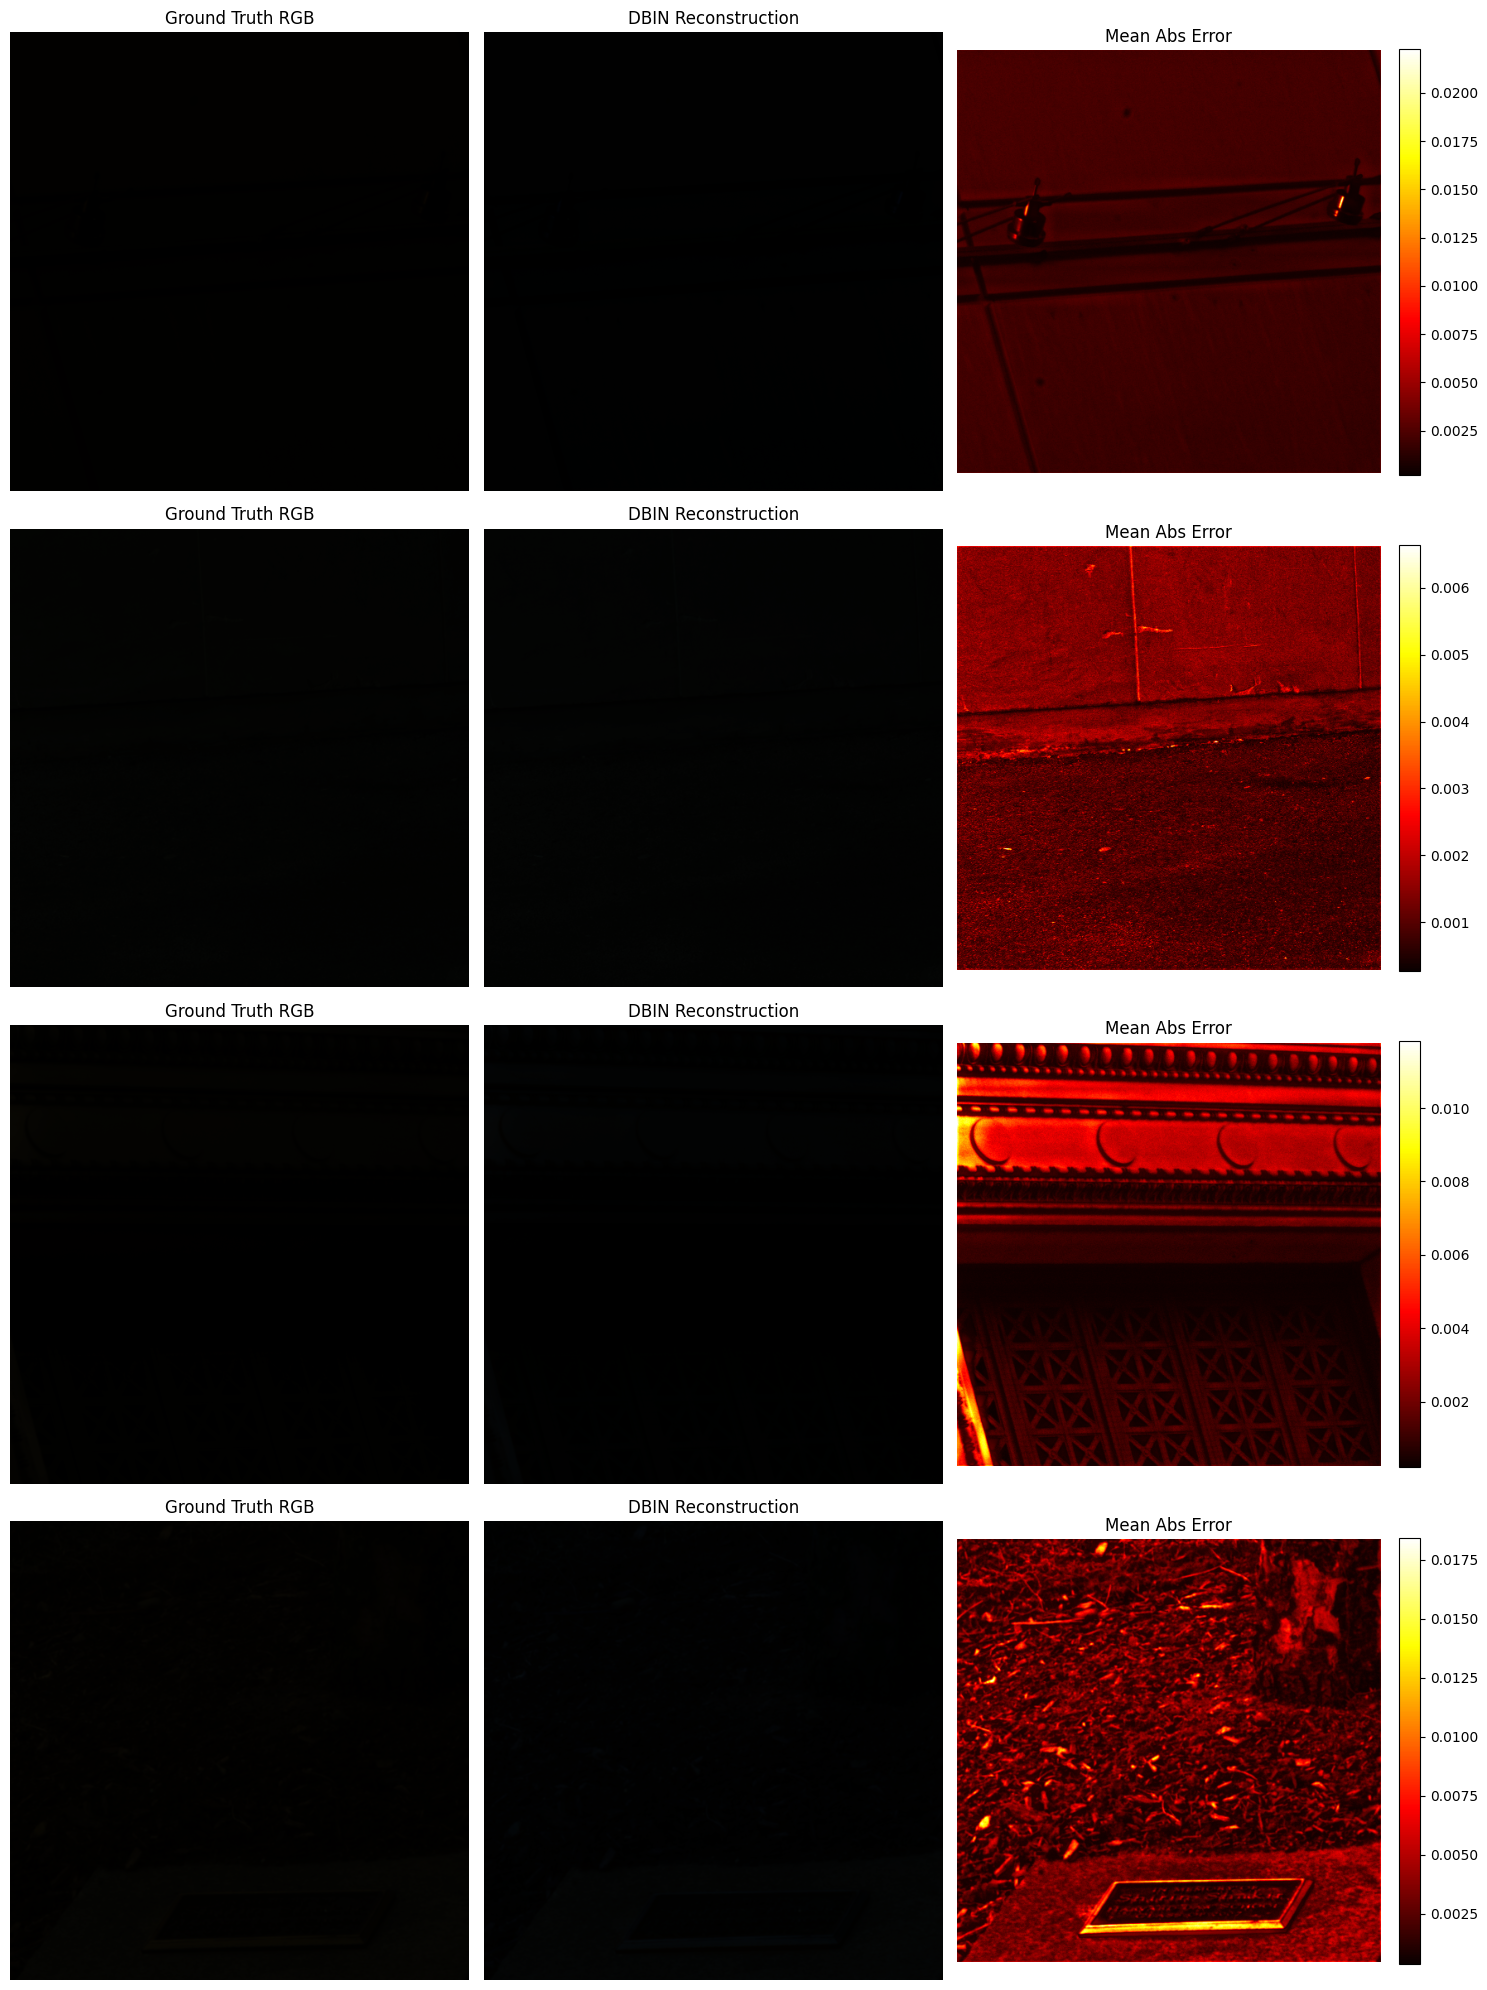

In [7]:
def to_rgb(hsi): 
    # Simple projection using bands 7, 15, 23
    return np.stack([hsi[..., 23], hsi[..., 15], hsi[..., 7]], axis=-1)

n = len(visualizations)
if n > 0:
    fig, axes = plt.subplots(n, 3, figsize=(15, 5*n))
    if n == 1: axes = axes[np.newaxis, :]
    for i in range(n):
        gt_rgb = to_rgb(visualizations[i]['gt'])
        out_rgb = to_rgb(visualizations[i]['out'])
        err = np.abs(visualizations[i]['gt'] - visualizations[i]['out']).mean(axis=-1)
        
        axes[i, 0].imshow(gt_rgb); axes[i, 0].set_title("Ground Truth RGB"); axes[i, 0].axis('off')
        axes[i, 1].imshow(out_rgb); axes[i, 1].set_title("DBIN Reconstruction"); axes[i, 1].axis('off')
        im = axes[i, 2].imshow(err, cmap='hot'); axes[i, 2].set_title("Mean Abs Error"); axes[i, 2].axis('off')
        plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()